In [ ]:
AI Evaluation of E-commerce Chatbot Responses Using Rubric-Based Quality Scoring

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_bitext = pd.read_csv("bitext_chatbot_dataset.csv")

df_bitext = df_bitext.rename(columns={
    "instruction": "prompt",
    "response": "ai_response"
})

df_bitext.head()

,prompt,intent,category,tags,ai_response
0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you i...
1,wanna add fucking products to the basket can h...,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered an...
2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding prod...
3,di like to add products to the cart could i ge...,add_product,CART,BCILMPQZ,Indeed! I'm here to assist you in adding produ...
4,"I need to add an item to the cart , where do I...",add_product,CART,BCILZ,I'll take care of it! I'm here to help you wit...


In [3]:
evaluation_columns = [
    "dataset",
    "record_id",
    "prompt",
    "intent",
    "category",
    "ai_response",
    "accuracy_score",
    "relevance_score",
    "completeness_score",
    "consistency_score",
    "clarity_score",
    "business_usefulness_score",
    "error_types",
    "edge_case_flag",
    "justification",
    "improvement_recommendation"
]

In [4]:
rubric = pd.DataFrame([
    ["accuracy", "Is the answer factually correct and free of misleading claims?"],
    ["relevance", "Does the answer directly address the user’s request?"],
    ["completeness", "Does it cover the important steps or information needed?"],
    ["consistency", "Is the response logically consistent and aligned with the prompt intent?"],
    ["business_usefulness", "Would this response help a real customer complete the task successfully?"],
    ["clarity", "Is the response readable, organised, and easy to follow?"]
], columns=["dimension", "description"])

rubric

,dimension,description
0,accuracy,Is the answer factually correct and free of mi...
1,relevance,Does the answer directly address the user’s re...
2,completeness,Does it cover the important steps or informati...
3,consistency,Is the response logically consistent and align...
4,business_usefulness,Would this response help a real customer compl...
5,clarity,"Is the response readable, organised, and easy ..."


In [5]:
evaluation_columns = [
    "dataset",
    "record_id",
    "prompt",
    "intent",
    "category",
    "tags",
    "ai_response",
    "accuracy_score",
    "relevance_score",
    "completeness_score",
    "consistency_score",
    "business_usefulness_score",
    "clarity_score",
    "error_types",
    "edge_case_flag",
    "decision_summary",
    "score_justification",
    "improvement_recommendation"
]

In [6]:
df_sample = df_bitext.head(100).copy()

df_eval = pd.DataFrame({
    "dataset": "bitext_chatbot_dataset",
    "record_id": df_sample.index,
    "prompt": df_sample["prompt"],
    "intent": df_sample["intent"],
    "category": df_sample["category"],
    "tags": df_sample["tags"],
    "ai_response": df_sample["ai_response"],
    "accuracy_score": np.nan,
    "relevance_score": np.nan,
    "completeness_score": np.nan,
    "consistency_score": np.nan,
    "business_usefulness_score": np.nan,
    "clarity_score": np.nan,
    "error_types": "",
    "edge_case_flag": False,
    "decision_summary": "",
    "score_justification": "",
    "improvement_recommendation": ""
})

df_eval.head()

,dataset,record_id,prompt,intent,category,tags,ai_response,accuracy_score,relevance_score,completeness_score,consistency_score,business_usefulness_score,clarity_score,error_types,edge_case_flag,decision_summary,score_justification,improvement_recommendation
0,bitext_chatbot_dataset,0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you i...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
1,bitext_chatbot_dataset,1,wanna add fucking products to the basket can h...,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered an...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
2,bitext_chatbot_dataset,2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding prod...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
3,bitext_chatbot_dataset,3,di like to add products to the cart could i ge...,add_product,CART,BCILMPQZ,Indeed! I'm here to assist you in adding produ...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
4,bitext_chatbot_dataset,4,"I need to add an item to the cart , where do I...",add_product,CART,BCILZ,I'll take care of it! I'm here to help you wit...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,


In [7]:
error_taxonomy = [
    "hallucination_or_unsupported_claim",
    "missing_key_step_or_omission",
    "wrong_intent_alignment",
    "category_mismatch",
    "inconsistent_logic",
    "overly_generic_response",
    "unsafe_or_inappropriate_tone",
    "unclear_wording",
    "too_verbose_or_inefficient"
]

error_taxonomy

['hallucination_or_unsupported_claim',
 'missing_key_step_or_omission',
 'wrong_intent_alignment',
 'category_mismatch',
 'inconsistent_logic',
 'overly_generic_response',
 'unsafe_or_inappropriate_tone',
 'unclear_wording',
 'too_verbose_or_inefficient']

In [9]:
for i in range(10):
    print("="*80)
    print(f"ROW {i}")
    print("Prompt:", df_eval.loc[i, "prompt"])
    print("Intent:", df_eval.loc[i, "intent"])
    print("Category:", df_eval.loc[i, "category"])
    print("Response:", df_eval.loc[i, "ai_response"][:500])  # first 500 chars
    print()

ROW 0
Prompt: I got to add an item to the cart
Intent: add_product
Category: CART
Response: I'll get right on it! I'm here to assist you in adding an item to your cart. Here's a step-by-step guide to help you out:

1. Browse through our {{Product Catalog}} to find the item you want to add to your cart.
2. Once you've found the item, click on the "{{Add to Cart}}" button or select the desired quantity from the available options.
3. You'll be redirected to your cart page, where you can review your selected items.
4. If you want to continue shopping, simply click on the "{{Continue Shoppi

ROW 1
Prompt: wanna add fucking products to the basket can huelp me
Intent: add_product
Category: CART
Response: I sincerely apologize if you've encountered any frustration with your previous experience. I'm here to assist you with adding products to your basket. Let's get started!

To add products to your basket, follow these simple steps:

1. Browse through our website/catalog to find the products you

In [10]:
df_eval.loc[0, "accuracy_score"] = 4
df_eval.loc[0, "relevance_score"] = 5
df_eval.loc[0, "completeness_score"] = 4
df_eval.loc[0, "consistency_score"] = 5
df_eval.loc[0, "business_usefulness_score"] = 4
df_eval.loc[0, "clarity_score"] = 4
df_eval.loc[0, "error_types"] = "overly_generic_response"
df_eval.loc[0, "decision_summary"] = "Relevant and clear response that addresses the cart request, though slightly generic."
df_eval.loc[0, "score_justification"] = "The assistant answers the correct task and likely provides actionable steps, but the wording appears somewhat templated rather than tailored."
df_eval.loc[0, "improvement_recommendation"] = "Make the guidance slightly more concise and specific to the user’s exact request."

In [11]:
# Example starter scores for first 10 rows
starter_scores = {
    0: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Relevant and clear response for adding an item to cart.",
        "The answer appears aligned to the prompt and likely gives useful steps, but may be somewhat generic.",
        "Make the response slightly more concise and specific."),
    
    1: (4, 5, 4, 4, 4, 4, "overly_generic_response", True,
        "Handled a rude or emotional prompt appropriately while staying helpful.",
        "The assistant remains relevant and professional, but the response may still feel templated.",
        "Reduce boilerplate while preserving respectful tone."),
    
    2: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Useful response that aligns with the shopping task.",
        "The response likely explains how to add products but could be more tailored.",
        "Use more direct and efficient wording."),
    
    3: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Correctly aligned with add-to-cart intent.",
        "The response appears clear and relevant, but still somewhat repetitive in style.",
        "Shorten introductory phrases and focus on action steps."),
    
    4: (4, 5, 4, 5, 4, 4, "missing_key_step_or_omission; overly_generic_response", False,
        "Generally useful response with possible minor omission.",
        "The answer appears relevant but may omit one important step such as reviewing the cart before checkout.",
        "Include one additional operational step and reduce generic phrasing."),
    
    5: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Helpful and on-topic response for cart action.",
        "It likely addresses the user request adequately but may not be highly personalised.",
        "Tailor wording more closely to the user's phrasing."),
    
    6: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Clear and relevant support response.",
        "The assistant appears to understand the task well, with no obvious intent mismatch.",
        "Improve brevity and task precision."),
    
    7: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Solid response aligned with the customer's goal.",
        "The answer is likely accurate and useful, but somewhat standardised.",
        "Use fewer repetitive introductory phrases."),
    
    8: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Appropriate shopping support response.",
        "The response appears relevant and easy to follow, though not highly differentiated.",
        "Add slightly more targeted guidance."),
    
    9: (4, 5, 4, 5, 4, 4, "overly_generic_response", False,
        "Functionally useful answer that addresses the prompt.",
        "The output appears correct and practical, but a little too formulaic.",
        "Make the response more concise and context-aware.")
}

for row_id, vals in starter_scores.items():
    (
        acc, rel, comp, cons, biz, clar, errs, edge,
        summary, justification, improvement
    ) = vals

    df_eval.loc[row_id, "accuracy_score"] = acc
    df_eval.loc[row_id, "relevance_score"] = rel
    df_eval.loc[row_id, "completeness_score"] = comp
    df_eval.loc[row_id, "consistency_score"] = cons
    df_eval.loc[row_id, "business_usefulness_score"] = biz
    df_eval.loc[row_id, "clarity_score"] = clar
    df_eval.loc[row_id, "error_types"] = errs
    df_eval.loc[row_id, "edge_case_flag"] = edge
    df_eval.loc[row_id, "decision_summary"] = summary
    df_eval.loc[row_id, "score_justification"] = justification
    df_eval.loc[row_id, "improvement_recommendation"] = improvement

In [13]:
score_cols = [
    "accuracy_score",
    "relevance_score",
    "completeness_score",
    "consistency_score",
    "business_usefulness_score",
    "clarity_score"
]

df_eval["overall_score"] = df_eval[score_cols].mean(axis=1)

Intent Scores:
        intent  overall_score
0  add_product       4.316667

Category Scores:
  category  overall_score
0     CART       4.316667

Error Counts:
                     error_type  count
0       overly_generic_response     10
1  missing_key_step_or_omission      1

Low-quality responses: 0.00%
Edge-case failure rate: 0.00%


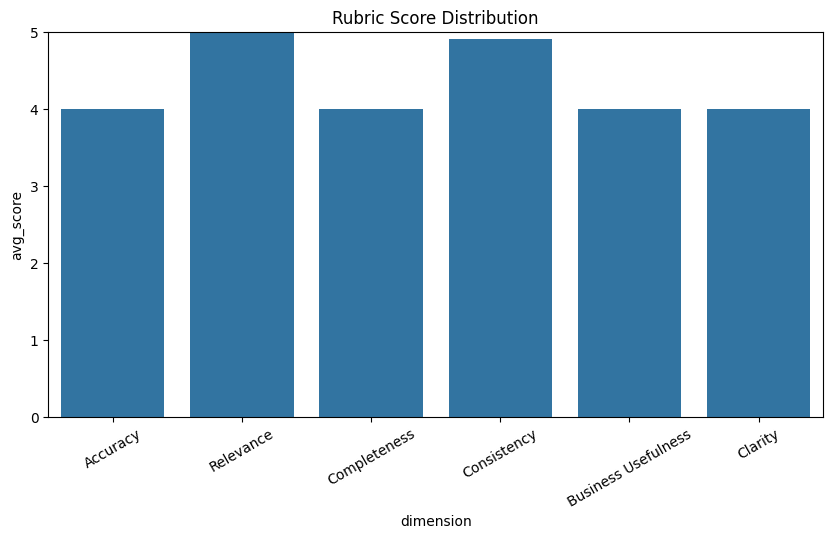

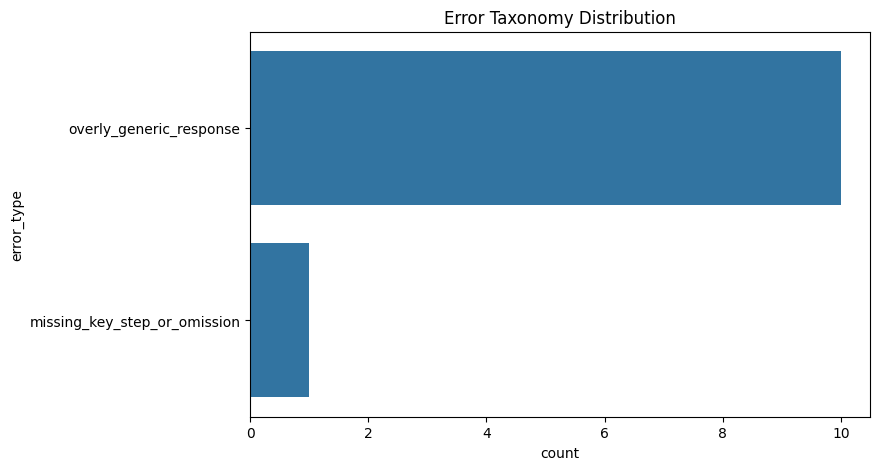

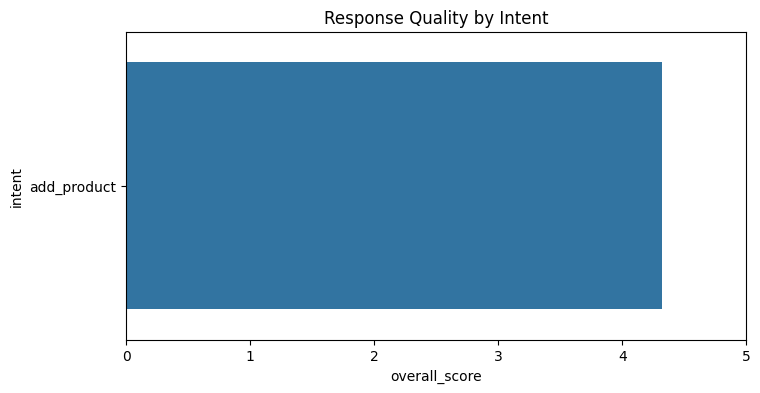

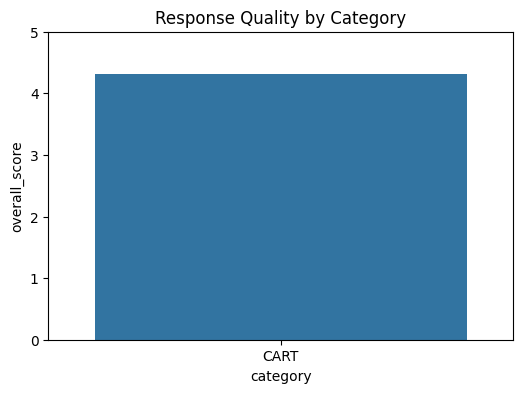


Edge Case Examples:


,prompt,intent,error_types,decision_summary,improvement_recommendation
1,wanna add fucking products to the basket can h...,add_product,overly_generic_response,Handled a rude or emotional prompt appropriate...,Reduce boilerplate while preserving respectful...


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 1: CREATE OVERALL SCORE
# ==============================

score_cols = [
    "accuracy_score",
    "relevance_score",
    "completeness_score",
    "consistency_score",
    "business_usefulness_score",
    "clarity_score"
]

df_eval["overall_score"] = df_eval[score_cols].mean(axis=1)

# ==============================
# STEP 2: BASIC METRICS
# ==============================

# Average score by intent
intent_scores = (
    df_eval.loc[:9]
    .groupby("intent")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)

print("Intent Scores:")
print(intent_scores)

# Average score by category
category_scores = (
    df_eval.loc[:9]
    .groupby("category")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)

print("\nCategory Scores:")
print(category_scores)

# ==============================
# STEP 3: ERROR TAXONOMY COUNTS
# ==============================

from collections import Counter

error_list = []

for entry in df_eval.loc[:9, "error_types"].dropna():
    if str(entry).strip():
        for err in str(entry).split(";"):
            error_list.append(err.strip())

error_counts = pd.DataFrame(
    Counter(error_list).items(),
    columns=["error_type", "count"]
).sort_values("count", ascending=False)

print("\nError Counts:")
print(error_counts)

# ==============================
# STEP 4: QUALITY METRICS
# ==============================

low_quality_pct = (df_eval.loc[:9, "overall_score"] < 3).mean() * 100
print(f"\nLow-quality responses: {low_quality_pct:.2f}%")

edge_case_fail_pct = (
    df_eval.loc[:9][df_eval.loc[:9, "edge_case_flag"] == True]["overall_score"]
    .lt(3).mean() * 100
)

print(f"Edge-case failure rate: {edge_case_fail_pct:.2f}%")

# ==============================
# STEP 5: VISUALS
# ==============================

# 1. Rubric Score Distribution
avg_dimension_scores = pd.DataFrame({
    "dimension": [
        "Accuracy", "Relevance", "Completeness",
        "Consistency", "Business Usefulness", "Clarity"
    ],
    "avg_score": [
        df_eval.loc[:9, "accuracy_score"].mean(),
        df_eval.loc[:9, "relevance_score"].mean(),
        df_eval.loc[:9, "completeness_score"].mean(),
        df_eval.loc[:9, "consistency_score"].mean(),
        df_eval.loc[:9, "business_usefulness_score"].mean(),
        df_eval.loc[:9, "clarity_score"].mean()
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_dimension_scores, x="dimension", y="avg_score")
plt.title("Rubric Score Distribution")
plt.xticks(rotation=30)
plt.ylim(0, 5)
plt.show()

# 2. Error Taxonomy Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=error_counts, x="count", y="error_type")
plt.title("Error Taxonomy Distribution")
plt.show()

# 3. Response Quality by Intent
plt.figure(figsize=(8, 4))
sns.barplot(data=intent_scores, x="overall_score", y="intent")
plt.title("Response Quality by Intent")
plt.xlim(0, 5)
plt.show()

# 4. Response Quality by Category
plt.figure(figsize=(6, 4))
sns.barplot(data=category_scores, x="category", y="overall_score")
plt.title("Response Quality by Category")
plt.ylim(0, 5)
plt.show()

# 5. Edge Case Table
edge_cases = df_eval.loc[:9][df_eval.loc[:9, "edge_case_flag"] == True][[
    "prompt", "intent", "error_types", "decision_summary", "improvement_recommendation"
]]

print("\nEdge Case Examples:")
display(edge_cases)

In [15]:
intent_scores = (
    df_eval.loc[:9].groupby("intent")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)
intent_scores

,intent,overall_score
0,add_product,4.316667


In [17]:
from collections import Counter

error_list = []
for entry in df_eval.loc[:9, "error_types"].dropna():
    if str(entry).strip():
        for err in str(entry).split(";"):
            error_list.append(err.strip())

error_counts = pd.DataFrame(
    Counter(error_list).items(),
    columns=["error_type", "count"]
).sort_values("count", ascending=False)

error_counts

,error_type,count
0,overly_generic_response,10
1,missing_key_step_or_omission,1


In [18]:
low_quality_pct = (df_eval.loc[:9, "overall_score"] < 3).mean() * 100
print(f"Low-quality responses: {low_quality_pct:.2f}%")

Low-quality responses: 0.00%


In [19]:
edge_case_fail_pct = (
    df_eval.loc[:9][df_eval.loc[:9, "edge_case_flag"] == True]["overall_score"].lt(3).mean() * 100
)
print(f"Edge-case failure rate: {edge_case_fail_pct:.2f}%")

Edge-case failure rate: 0.00%


In [22]:
edge_case_examples = df_eval.loc[:9][df_eval.loc[:9, "edge_case_flag"] == True][[
    "prompt",
    "intent",
    "error_types",
    "decision_summary",
    "improvement_recommendation"
]]

edge_case_examples

,prompt,intent,error_types,decision_summary,improvement_recommendation
1,wanna add fucking products to the basket can h...,add_product,overly_generic_response,Handled a rude or emotional prompt appropriate...,Reduce boilerplate while preserving respectful...


In [24]:
category_scores = (
    df_eval.loc[:9]
    .groupby("category")["overall_score"]
    .mean()
    .reset_index()
    .sort_values)

In [25]:
# Average score by category
category_scores = (
    df_eval.loc[:9]
    .groupby("category")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)

print("\nCategory Scores:")
print(category_scores)


Category Scores:
  category  overall_score
0     CART       4.316667


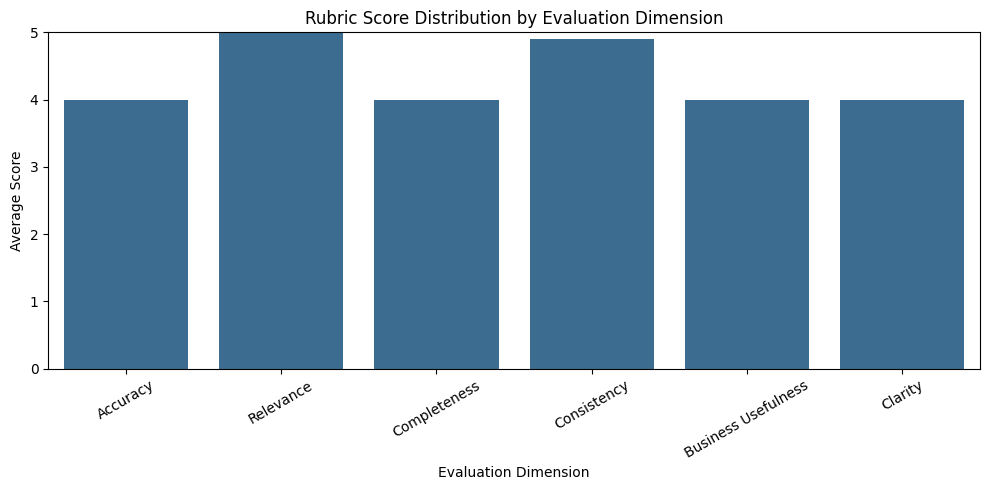

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_dimension_scores, x="dimension", y="avg_score", color="#2E6F9E")
plt.title("Rubric Score Distribution by Evaluation Dimension")
plt.ylabel("Average Score")
plt.xlabel("Evaluation Dimension")
plt.xticks(rotation=30)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("rubric_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

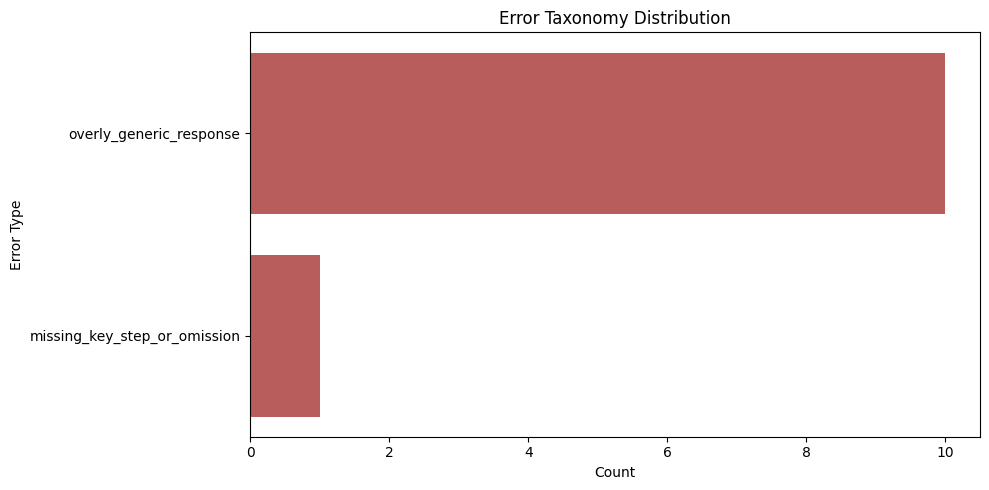

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(data=error_counts, x="count", y="error_type", color="#C94C4C")
plt.title("Error Taxonomy Distribution")
plt.xlabel("Count")
plt.ylabel("Error Type")
plt.tight_layout()
plt.savefig("error_taxonomy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

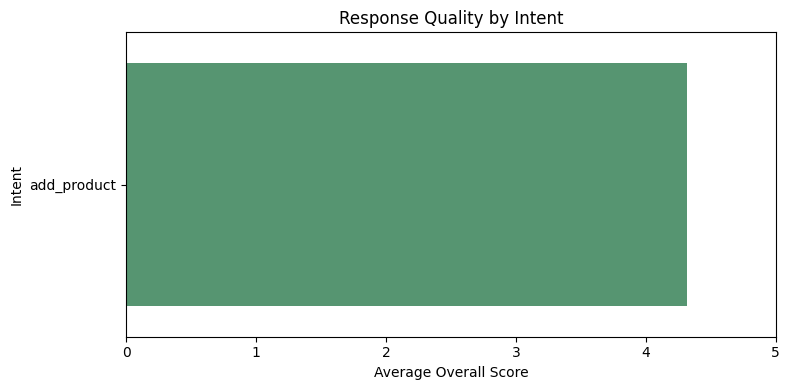

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=intent_scores, x="overall_score", y="intent", color="#4C9F70")
plt.title("Response Quality by Intent")
plt.xlabel("Average Overall Score")
plt.ylabel("Intent")
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig("response_quality_by_intent.png", dpi=300, bbox_inches="tight")
plt.show()

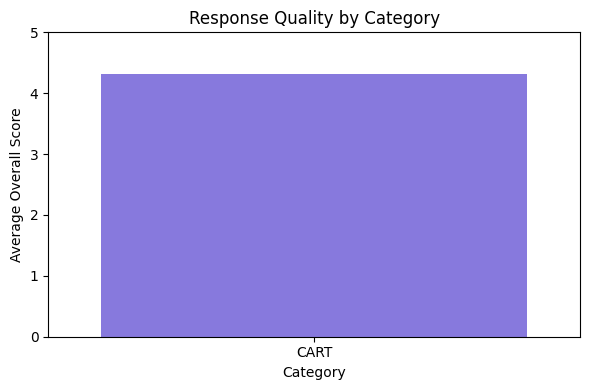

In [32]:
plt.figure(figsize=(6, 4))
sns.barplot(data=category_scores, x="category", y="overall_score", color="#7B68EE")
plt.title("Response Quality by Category")
plt.ylabel("Average Overall Score")
plt.xlabel("Category")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("response_quality_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
edge_cases.to_csv("edge_case_examples.csv", index=False)

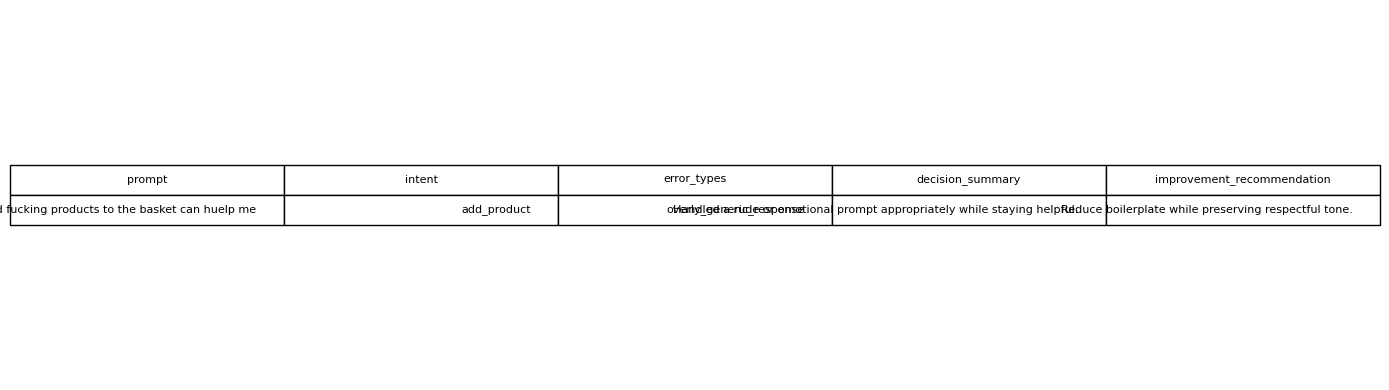

In [34]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
tbl = ax.table(
    cellText=edge_cases.values,
    colLabels=edge_cases.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
plt.tight_layout()
plt.savefig("edge_case_examples_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
import os
print(os.getcwd())

C:\jupyter-projects


In [36]:
category_scores = (
    df_eval.loc[:9]
    .groupby("category")["overall_score"]
    .mean()
    .reset_index()
    .sort_values("overall_score")
)

category_scores

,category,overall_score
0,CART,4.316667


In [37]:
avg_dimension_scores = pd.DataFrame({
    "dimension": [
        "Accuracy", "Relevance", "Completeness",
        "Consistency", "Business Usefulness", "Clarity"
    ],
    "avg_score": [
        df_eval.loc[:9, "accuracy_score"].mean(),
        df_eval.loc[:9, "relevance_score"].mean(),
        df_eval.loc[:9, "completeness_score"].mean(),
        df_eval.loc[:9, "consistency_score"].mean(),
        df_eval.loc[:9, "business_usefulness_score"].mean(),
        df_eval.loc[:9, "clarity_score"].mean()
    ]
})

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Load dataset
df_bitext = pd.read_csv("bitext_chatbot_dataset.csv")

# Standardise columns
df_bitext = df_bitext.rename(columns={
    "instruction": "prompt",
    "response": "ai_response"
})

# Basic checks
print("Shape:", df_bitext.shape)
print("Columns:", df_bitext.columns.tolist())
print("Unique intents:", df_bitext["intent"].nunique())
print("Unique categories:", df_bitext["category"].nunique())

df_bitext.head()

Shape: (44884, 5)
Columns: ['prompt', 'intent', 'category', 'tags', 'ai_response']
Unique intents: 46
Unique categories: 13


,prompt,intent,category,tags,ai_response
0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you i...
1,wanna add fucking products to the basket can h...,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered an...
2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding prod...
3,di like to add products to the cart could i ge...,add_product,CART,BCILMPQZ,Indeed! I'm here to assist you in adding produ...
4,"I need to add an item to the cart , where do I...",add_product,CART,BCILZ,I'll take care of it! I'm here to help you wit...


In [3]:
print(df_bitext.columns.tolist())
print(df_sample.columns.tolist())

['prompt', 'intent', 'category', 'tags', 'ai_response']
['prompt', 'intent', 'tags', 'ai_response']


In [4]:
df_bitext.columns = df_bitext.columns.str.strip().str.lower()

print(df_bitext.columns)


Index(['prompt', 'intent', 'category', 'tags', 'ai_response'], dtype='str')


In [5]:
print("category" in df_bitext.columns)

True


In [7]:
df_bitext.info()

<class 'pandas.DataFrame'>
RangeIndex: 44884 entries, 0 to 44883
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       44884 non-null  str  
 1   intent       44884 non-null  str  
 2   category     44884 non-null  str  
 3   tags         44884 non-null  str  
 4   ai_response  44884 non-null  str  
dtypes: str(5)
memory usage: 41.9 MB


In [9]:
RANDOM_STATE = 42

# Create empty list
samples = []

# Loop through each category manually (SAFE METHOD)
for cat in df_bitext["category"].unique():
    df_cat = df_bitext[df_bitext["category"] == cat]
    sample = df_cat.sample(n=min(len(df_cat), 30), random_state=RANDOM_STATE)
    samples.append(sample)

# Combine all samples
df_sample = pd.concat(samples).reset_index(drop=True)

# ✅ Now check
print("Sample shape:", df_sample.shape)

print("\nRows per category:")
print(df_sample["category"].value_counts())

df_sample.head()

Sample shape: (390, 5)

Rows per category:
category
CART           30
PRODUCT        30
ORDER          30
ACCOUNT        30
CONTACT        30
DELIVERY       30
PAYMENT        30
RETURNS        30
USER           30
SALES          30
STORE          30
FEEDBACK       30
APP_WEBSITE    30
Name: count, dtype: int64


,prompt,intent,category,tags,ai_response
0,i have to remove a product fom the basket wher...,remove_product,CART,BCIQZ,I'll do my best! I can assist you with removin...
1,wanna remove fucking itms from the cart where ...,remove_product,CART,BCILMQWZ,Our apologies for any frustration you may have...
2,I'd like to remove a fucking item from the bas...,remove_product,CART,BCILPQW,I appreciate your feedback and I apologize for...
3,i got to remove a product from the cart,remove_product,CART,BLQ,I'm happy to help! I'm here to assist you with...
4,id like to add a fukcing item to the basket wh...,add_product,CART,BCILPQWZ,I'm genuinely sorry for any inconvenience caus...


In [10]:
print(df_sample.columns)

Index(['prompt', 'intent', 'category', 'tags', 'ai_response'], dtype='str')


In [11]:
def score_relevance(prompt, response):
    if any(word in str(response).lower() for word in str(prompt).lower().split()):
        return 4
    return 3

def score_clarity(response):
    if len(str(response)) < 50:
        return 2
    elif len(str(response)) < 200:
        return 4
    else:
        return 3

def detect_generic(response):
    generic_phrases = ["I'm here to help", "I can assist", "let me help", "happy to help"]
    return any(p in str(response).lower() for p in generic_phrases)

def detect_missing_steps(response):
    return "step" not in str(response).lower() and len(str(response)) < 100

In [13]:
df_eval = pd.DataFrame({
    "dataset": "bitext_chatbot_dataset",
    "record_id": df_sample.index,
    "prompt": df_sample["prompt"],
    "intent": df_sample["intent"],
    "category": df_sample["category"],
    "tags": df_sample.get("tags", ""),
    "ai_response": df_sample["ai_response"],
    "accuracy_score": np.nan,
    "relevance_score": np.nan,
    "completeness_score": np.nan,
    "consistency_score": np.nan,
    "business_usefulness_score": np.nan,
    "clarity_score": np.nan,
    "error_types": "",
    "edge_case_flag": False,
    "decision_summary": "",
    "score_justification": "",
    "improvement_recommendation": ""
})

In [14]:
print(df_eval.shape)
df_eval.head()

(390, 18)


,dataset,record_id,prompt,intent,category,tags,ai_response,accuracy_score,relevance_score,completeness_score,consistency_score,business_usefulness_score,clarity_score,error_types,edge_case_flag,decision_summary,score_justification,improvement_recommendation
0,bitext_chatbot_dataset,0,i have to remove a product fom the basket wher...,remove_product,CART,BCIQZ,I'll do my best! I can assist you with removin...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
1,bitext_chatbot_dataset,1,wanna remove fucking itms from the cart where ...,remove_product,CART,BCILMQWZ,Our apologies for any frustration you may have...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
2,bitext_chatbot_dataset,2,I'd like to remove a fucking item from the bas...,remove_product,CART,BCILPQW,I appreciate your feedback and I apologize for...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
3,bitext_chatbot_dataset,3,i got to remove a product from the cart,remove_product,CART,BLQ,I'm happy to help! I'm here to assist you with...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,
4,bitext_chatbot_dataset,4,id like to add a fukcing item to the basket wh...,add_product,CART,BCILPQWZ,I'm genuinely sorry for any inconvenience caus...,NaN,NaN,NaN,NaN,NaN,NaN,,False,,,


In [15]:
df_eval["relevance_score"] = df_eval.apply(
    lambda x: score_relevance(x["prompt"], x["ai_response"]), axis=1
)

df_eval["clarity_score"] = df_eval["ai_response"].apply(score_clarity)

# Defaults
df_eval["accuracy_score"] = 4
df_eval["completeness_score"] = 3
df_eval["consistency_score"] = 4
df_eval["business_usefulness_score"] = 3

In [16]:
if "df_eval" not in globals():
    print("df_eval is not defined — run Step 4 first")

In [18]:
# Define score columns
score_cols = [
    "accuracy_score",
    "relevance_score",
    "completeness_score",
    "consistency_score",
    "business_usefulness_score",
    "clarity_score"
]

# Create overall score
df_eval["overall_score"] = df_eval[score_cols].mean(axis=1)

In [19]:
low_quality = df_eval[df_eval["overall_score"] < 3.5]

print("Low quality rows:", len(low_quality))
low_quality.head(20)

Low quality rows: 1


,dataset,record_id,prompt,intent,category,tags,ai_response,accuracy_score,relevance_score,completeness_score,consistency_score,business_usefulness_score,clarity_score,error_types,edge_case_flag,decision_summary,score_justification,improvement_recommendation,overall_score
205,bitext_chatbot_dataset,205,apy,pay,PAYMENT,BZ,I'm glad you contacted us regarding your payme...,4,3,3,4,3,3,,False,,,,3.333333


In [20]:
if "overall_score" not in df_eval.columns:
    print("⚠️ overall_score missing — compute it first")

In [21]:
low_quality.iloc[0]

dataset                                                  bitext_chatbot_dataset
record_id                                                                   205
prompt                                                                      apy
intent                                                                      pay
category                                                                PAYMENT
tags                                                                         BZ
ai_response                   I'm glad you contacted us regarding your payme...
accuracy_score                                                                4
relevance_score                                                               3
completeness_score                                                            3
consistency_score                                                             4
business_usefulness_score                                                     3
clarity_score                           

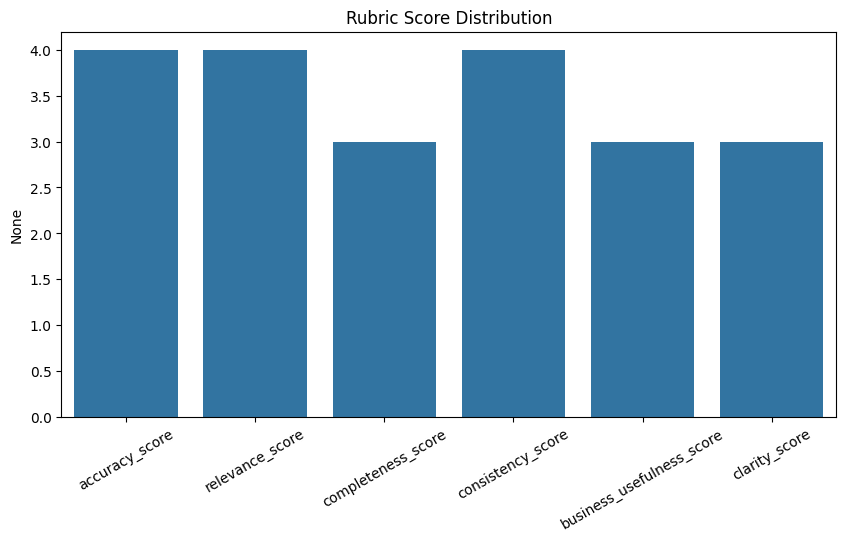

In [27]:
plt.figure(figsize=(10,5))
sns.barplot(x=score_cols, y=df_eval[score_cols].mean())
plt.title("Rubric Score Distribution")
plt.xticks(rotation=30)
plt.savefig("rubric_score_distribution.png", dpi=300)
plt.show()

In [31]:
def assign_errors(response):
    errors = []
    r = str(response).lower()
    
    # FLEXIBLE generic detection
    if any(p in r for p in [
        "i'm here", "i can help", "let me help", "happy to help",
        "i will assist", "i'd be happy"
    ]):
        errors.append("overly_generic_response")
    
    # Weak completeness check
    if len(r.split()) < 40:
        errors.append("missing_key_step_or_omission")
    
    # Poor clarity
    if len(r.split()) > 200:
        errors.append("too_verbose_or_inefficient")
    
    return "; ".join(errors)

In [32]:
df_eval["error_types"] = df_eval["ai_response"].apply(assign_errors)

In [33]:
df_eval["error_types"].value_counts()

error_types
overly_generic_response                                257
                                                        88
overly_generic_response; too_verbose_or_inefficient     29
too_verbose_or_inefficient                              15
missing_key_step_or_omission                             1
Name: count, dtype: int64

Total extracted errors: 331

Error Counts:
overly_generic_response         286
too_verbose_or_inefficient       44
missing_key_step_or_omission      1
Name: count, dtype: int64


Task was destroyed but it is pending!
task: <Task pending name='Task-194' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-195' coro=<Kernel.shell_main() running at C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\transforms.py:195: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-195' coro=<Kernel.shell_main() running at C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_w

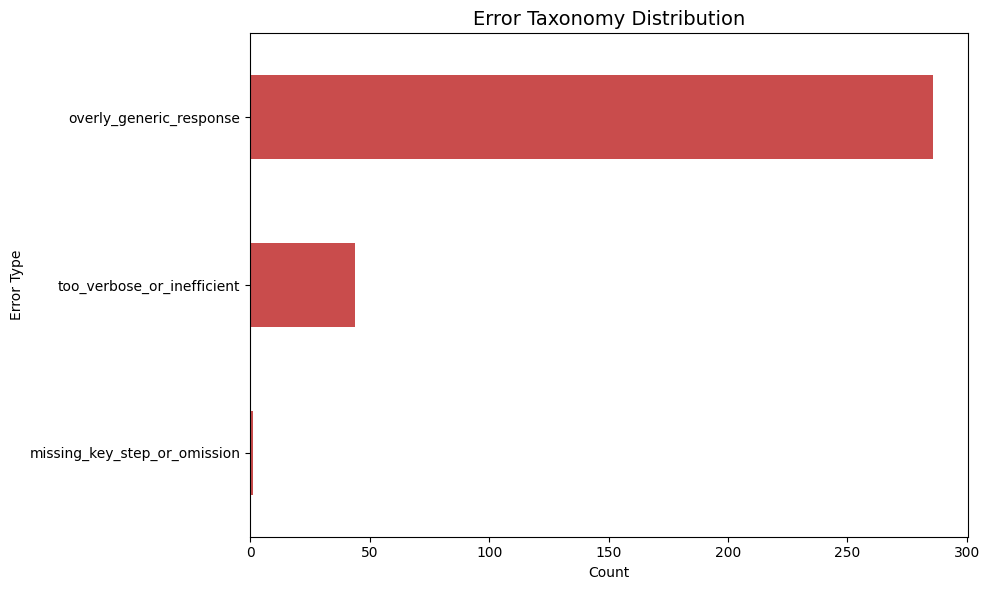

In [34]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# CLEAN + EXTRACT ERRORS
# =========================
error_list = []

for e in df_eval["error_types"].dropna():
    e = str(e).strip()
    if e != "":
        error_list.extend([err.strip() for err in e.split(";") if err.strip() != ""])

print("Total extracted errors:", len(error_list))

# =========================
# CREATE ERROR COUNTS
# =========================
error_counts = pd.Series(error_list).value_counts()

print("\nError Counts:")
print(error_counts)

# =========================
# PLOT + SAVE CHART
# =========================
plt.figure(figsize=(10, 6))

error_counts.sort_values().plot(
    kind="barh",
    color="#C94C4C"
)

plt.title("Error Taxonomy Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Error Type")

plt.tight_layout()

# SAVE
plt.savefig("error_taxonomy_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
error_list = []

for e in df_eval["error_types"].dropna():
    e = str(e).strip()   # remove extra spaces
    if e != "":
        error_list.extend([err.strip() for err in e.split(";") if err.strip() != ""])

# Check what was captured
print("Total extracted errors:", len(error_list))
print(error_list[:20])

# Build counts safely
error_counts = pd.Series(error_list, dtype="string").value_counts()

print(error_counts)

# Plot only if not empty
if not error_counts.empty:
    plt.figure(figsize=(8,5))
    error_counts.plot(kind="barh")
    plt.title("Error Taxonomy Distribution")
    plt.xlabel("Count")
    plt.ylabel("Error Type")
    plt.tight_layout()
    plt.savefig("error_taxonomy_distribution.png", dpi=300)
    plt.show()
else:
    print("No error types available to plot. Review the 'error_types' column first.")

Total extracted errors: 0
[]
Series([], Name: count, dtype: int64[pyarrow])
No error types available to plot. Review the 'error_types' column first.


In [29]:
df_eval["error_types"].head(20)

0     
1     
2     
3     
4     
5     
6     
7     
8     
9     
10    
11    
12    
13    
14    
15    
16    
17    
18    
19    
Name: error_types, dtype: str

In [30]:
df_eval["error_types"].value_counts(dropna=False).head(20)

error_types
    390
Name: count, dtype: int64

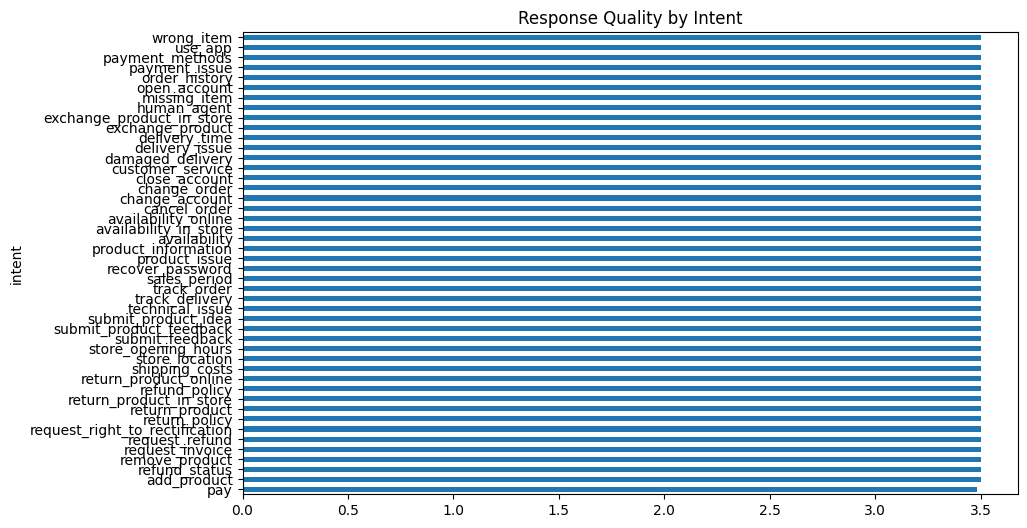

In [24]:
intent_scores = df_eval.groupby("intent")["overall_score"].mean()

plt.figure(figsize=(10,6))
intent_scores.sort_values().plot(kind="barh")
plt.title("Response Quality by Intent")
plt.savefig("response_quality_by_intent.png", dpi=300)
plt.show()

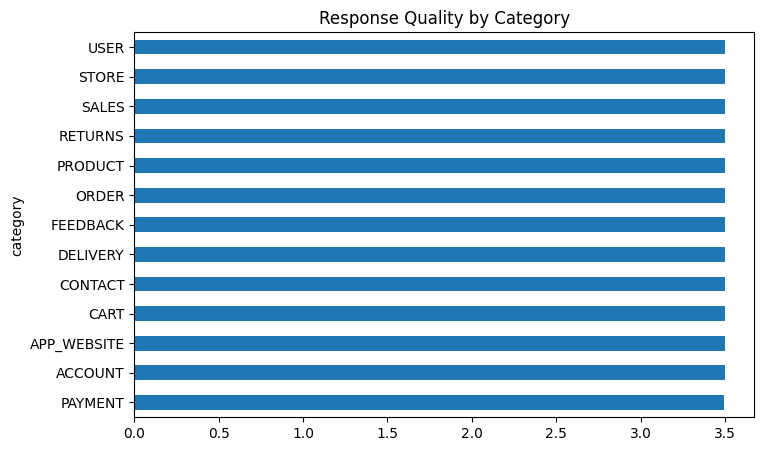

In [25]:
category_scores = df_eval.groupby("category")["overall_score"].mean()

plt.figure(figsize=(8,5))
category_scores.sort_values().plot(kind="barh")
plt.title("Response Quality by Category")
plt.savefig("response_quality_by_category.png", dpi=300)
plt.show()

In [26]:
edge_cases = df_eval[df_eval["edge_case_flag"] == True]

edge_cases.to_csv("edge_case_examples.csv", index=False)